# CTE-Net — Characterization of Transfer Entropy values

Este cuaderno caracteriza **únicamente las matrices TE del conjunto test de los cinco folds**, es decir, las representaciones *out-of-fold* usadas para interpretación.

Se reporta:

- rango mínimo–máximo de las conexiones TE fuera de la diagonal;
- número y porcentaje de valores negativos;
- valores no finitos;
- percentiles y distribución;
- resumen por fold y por sujeto;
- magnitud de la cola negativa para distinguir valores negativos pequeños de valores sustancialmente negativos.

La diagonal se excluye del análisis porque fue fijada en cero por construcción.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/kaggle/input/datasets/alejandragomezr/matrices-te-all-folds")

# Detectar automáticamente la carpeta que contiene fold_1, ..., fold_5
candidates = [
    ROOT / "TE_matrices_all_folds_train_validation_test_diag_zero",
    *[p for p in ROOT.iterdir() if p.is_dir() and p.name.startswith("TE_matrices")]
]

DATA_DIR = None
for p in candidates:
    if p.exists() and (p / "fold_1").exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        f"No se encontró dentro de {ROOT} una carpeta con fold_1, ..., fold_5."
    )

print("DATA_DIR:", DATA_DIR)

for fold in range(1, 6):
    path = DATA_DIR / f"fold_{fold}" / "test"
    print(f"fold_{fold}/test:", "OK" if path.exists() else "NO ENCONTRADO")

DATA_DIR: /kaggle/input/datasets/alejandragomezr/matrices-te-all-folds/TE_matrices_all_folds_train_validation_test_diag_zero
fold_1/test: OK
fold_2/test: OK
fold_3/test: OK
fold_4/test: OK
fold_5/test: OK


In [2]:
# ============================================================
# Carga y caracterización
# ============================================================

N_CHANNELS = 19
OFF_DIAG_MASK = ~np.eye(N_CHANNELS, dtype=bool)

all_values = []
subject_rows = []
fold_rows = []

for fold in range(1, 6):
    fold_dir = DATA_DIR / f"fold_{fold}" / "test"
    files = sorted(fold_dir.glob("*/*.npz"))

    if not files:
        raise FileNotFoundError(f"No se encontraron .npz en {fold_dir}")

    fold_values = []
    fold_nonfinite = 0
    fold_total_raw = 0

    print(f"\nFold {fold}: {len(files)} sujetos")

    for file_path in files:
        with np.load(file_path, allow_pickle=True) as data:
            if "TE_matrices" not in data.files:
                raise KeyError(
                    f"{file_path.name} no contiene la clave 'TE_matrices'. "
                    f"Claves disponibles: {data.files}"
                )

            te = np.asarray(data["TE_matrices"], dtype=np.float64)

            if te.ndim != 3 or te.shape[1:] != (N_CHANNELS, N_CHANNELS):
                raise ValueError(
                    f"{file_path.name}: forma inesperada {te.shape}; "
                    f"se esperaba (n_windows, 19, 19)."
                )

            subject_id = (
                str(data["subject_id"].item())
                if "subject_id" in data.files
                else file_path.stem
            )
            class_name = (
                str(data["class_name"].item())
                if "class_name" in data.files
                else file_path.parent.name
            )

        # Solo conexiones dirigidas fuera de la diagonal
        vals_raw = te[:, OFF_DIAG_MASK].reshape(-1)
        fold_total_raw += vals_raw.size

        finite_mask = np.isfinite(vals_raw)
        n_nonfinite = int((~finite_mask).sum())
        fold_nonfinite += n_nonfinite

        vals = vals_raw[finite_mask]

        if vals.size == 0:
            raise ValueError(f"{file_path.name}: no contiene valores TE finitos.")

        all_values.append(vals)
        fold_values.append(vals)

        subject_rows.append({
            "fold": fold,
            "subject_id": subject_id,
            "class_name": class_name,
            "n_windows": te.shape[0],
            "n_coefficients": vals.size,
            "n_nonfinite": n_nonfinite,
            "te_min": float(vals.min()),
            "te_max": float(vals.max()),
            "te_mean": float(vals.mean()),
            "te_median": float(np.median(vals)),
            "n_negative": int((vals < 0).sum()),
            "pct_negative": float(100 * (vals < 0).mean()),
        })

    fold_vals = np.concatenate(fold_values)

    fold_rows.append({
        "fold": fold,
        "n_subjects": len(files),
        "n_coefficients": fold_vals.size,
        "n_nonfinite": fold_nonfinite,
        "te_min": float(fold_vals.min()),
        "te_max": float(fold_vals.max()),
        "te_mean": float(fold_vals.mean()),
        "te_median": float(np.median(fold_vals)),
        "n_negative": int((fold_vals < 0).sum()),
        "pct_negative": float(100 * (fold_vals < 0).mean()),
    })

values = np.concatenate(all_values)
subject_df = pd.DataFrame(subject_rows)
fold_df = pd.DataFrame(fold_rows)

print("\nTotal de coeficientes TE finitos:", f"{values.size:,}")
print("Total de sujetos:", len(subject_df))


Fold 1: 24 sujetos

Fold 2: 24 sujetos

Fold 3: 24 sujetos

Fold 4: 24 sujetos

Fold 5: 23 sujetos

Total de coeficientes TE finitos: 2,772,594
Total de sujetos: 119


In [3]:
# ============================================================
# Resumen global para responder al revisor
# ============================================================

negative = values[values < 0]

summary = {
    "n_subjects": int(len(subject_df)),
    "n_coefficients": int(values.size),
    "n_nonfinite": int(subject_df["n_nonfinite"].sum()),
    "te_min": float(values.min()),
    "te_max": float(values.max()),
    "te_mean": float(values.mean()),
    "te_std": float(values.std()),
    "te_median": float(np.median(values)),
    "q01": float(np.quantile(values, 0.01)),
    "q05": float(np.quantile(values, 0.05)),
    "q25": float(np.quantile(values, 0.25)),
    "q75": float(np.quantile(values, 0.75)),
    "q95": float(np.quantile(values, 0.95)),
    "q99": float(np.quantile(values, 0.99)),
    "n_negative": int((values < 0).sum()),
    "pct_negative": float(100 * (values < 0).mean()),
    "n_zero": int((values == 0).sum()),
    "pct_zero": float(100 * (values == 0).mean()),
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ["value"]
display(summary_df)

print("\n================ REVIEWER NUMBERS ================")
print(f"TE range             : [{summary['te_min']:.10g}, {summary['te_max']:.10g}]")
print(f"Negative coefficients: {summary['n_negative']:,} / {summary['n_coefficients']:,}")
print(f"Negative percentage  : {summary['pct_negative']:.6f}%")
print(f"Non-finite values     : {summary['n_nonfinite']:,}")

if negative.size:
    print(f"Most negative value   : {negative.min():.10g}")
    print(f"Median negative value : {np.median(negative):.10g}")
else:
    print("No negative TE values were observed.")

,value
n_subjects,1.190000e+02
n_coefficients,2.772594e+06
n_nonfinite,0.000000e+00
te_min,-8.005744e-02
te_max,5.156078e-01
te_mean,4.496624e-02
te_std,6.428703e-02
te_median,1.282601e-02
q01,-5.115828e-03
q05,-3.552437e-04



================ REVIEWER NUMBERS ================
TE range             : [-0.08005744219, 0.5156078339]
Negative coefficients: 278,901 / 2,772,594
Negative percentage  : 10.059208%
Non-finite values     : 0
Most negative value   : -0.08005744219
Median negative value : -0.0003477931023


In [4]:
# ============================================================
# ¿Los negativos son solo numéricamente pequeños?
# ============================================================

thresholds = [0, -1e-12, -1e-10, -1e-8, -1e-6, -1e-4, -1e-3, -1e-2]

rows = []
for t in thresholds:
    if t == 0:
        count = int((values < 0).sum())
        label = "TE < 0"
    else:
        count = int((values < t).sum())
        label = f"TE < {t:g}"

    rows.append({
        "threshold": label,
        "count": count,
        "percentage": 100 * count / values.size
    })

negative_tail_df = pd.DataFrame(rows)
display(negative_tail_df)

,threshold,count,percentage
0,TE < 0,278901,10.059208
1,TE < -1e-12,278249,10.035692
2,TE < -1e-10,278163,10.032590
3,TE < -1e-08,277394,10.004855
4,TE < -1e-06,260294,9.388104
5,TE < -0.0001,182343,6.576621
6,TE < -0.001,94868,3.421633
7,TE < -0.01,10604,0.382458


In [5]:
# ============================================================
# Resumen por fold
# ============================================================

display(fold_df)

print("\nRango global de mínimos por fold:",
      fold_df["te_min"].min(), "a", fold_df["te_min"].max())
print("Rango global de máximos por fold:",
      fold_df["te_max"].min(), "a", fold_df["te_max"].max())

,fold,n_subjects,n_coefficients,n_nonfinite,te_min,te_max,te_mean,te_median,n_negative,pct_negative
0,1,24,568404,0,-0.065201,0.454869,0.062064,0.022859,47608,8.375733
1,2,24,534204,0,-0.066946,0.463558,0.028125,0.007121,95644,17.904022
2,3,24,567378,0,-0.080057,0.515608,0.061195,0.016700,36680,6.464826
3,4,24,549936,0,-0.071425,0.488310,0.036727,0.012776,57737,10.498858
4,5,23,552672,0,-0.048527,0.393225,0.035198,0.013399,41232,7.460483



Rango global de mínimos por fold: -0.08005744218826294 a -0.048526763916015625
Rango global de máximos por fold: 0.3932245969772339 a 0.5156078338623047


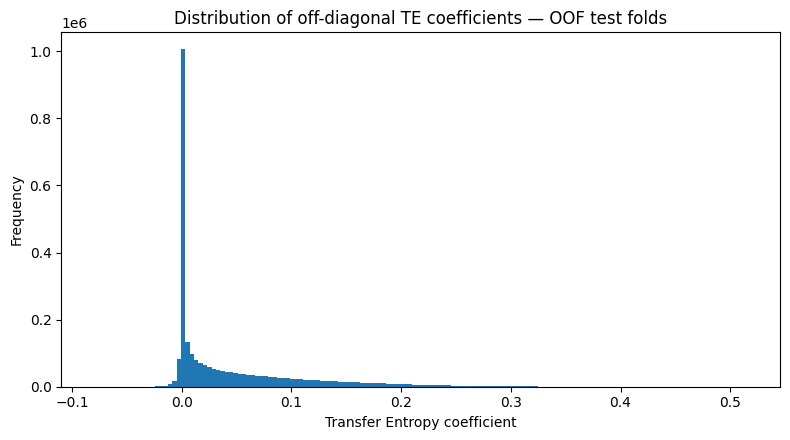

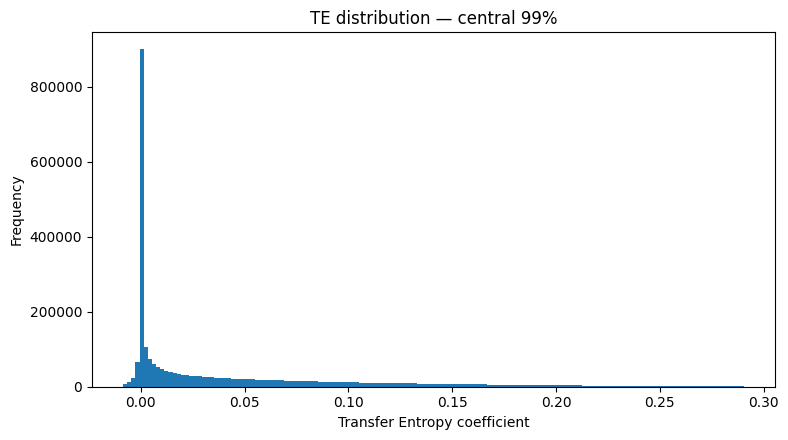

In [6]:
# ============================================================
# Distribución global
# ============================================================

plt.figure(figsize=(8, 4.5))
plt.hist(values, bins=150)
plt.xlabel("Transfer Entropy coefficient")
plt.ylabel("Frequency")
plt.title("Distribution of off-diagonal TE coefficients — OOF test folds")
plt.tight_layout()
plt.show()

# Vista robusta sin que los extremos oculten la mayor parte de la distribución
lo, hi = np.quantile(values, [0.005, 0.995])

plt.figure(figsize=(8, 4.5))
plt.hist(values[(values >= lo) & (values <= hi)], bins=150)
plt.xlabel("Transfer Entropy coefficient")
plt.ylabel("Frequency")
plt.title("TE distribution — central 99%")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Resumen por sujeto
# ============================================================

display(
    subject_df.sort_values("te_min")
    .reset_index(drop=True)
    .head(20)
)

print("\nSujetos con al menos un TE negativo:",
      int((subject_df["n_negative"] > 0).sum()),
      "/", len(subject_df))

,fold,subject_id,class_name,n_windows,n_coefficients,n_nonfinite,te_min,te_max,te_mean,te_median,n_negative,pct_negative
0,3,v181,TDAH,40,13680,0,-0.080057,0.396071,0.088542,0.035072,562,4.108187
1,3,v288,TDAH,77,26334,0,-0.078570,0.458195,0.091501,0.043148,1089,4.135338
2,4,v29p,TDAH,93,31806,0,-0.071425,0.354769,0.069906,0.056289,1906,5.992580
3,3,v213,TDAH,47,16074,0,-0.071180,0.507843,0.083819,0.039463,750,4.665920
4,2,v51p,Control,30,10260,0,-0.066946,0.210522,0.015362,0.005340,2336,22.768031
5,1,v44p,Control,43,14706,0,-0.065201,0.250594,0.021044,0.005009,2375,16.149871
6,3,v27p,TDAH,111,37962,0,-0.061372,0.402835,0.056637,0.039375,1845,4.860123
7,1,v30p,TDAH,83,28386,0,-0.058804,0.388664,0.079420,0.062689,1931,6.802649
8,3,v183,TDAH,71,24282,0,-0.058389,0.413310,0.057792,0.024707,2273,9.360843
9,1,v40p,TDAH,77,26334,0,-0.057244,0.395419,0.073542,0.060665,1189,4.515076



Sujetos con al menos un TE negativo: 119 / 119


In [8]:
# ============================================================
# Guardar resultados
# ============================================================

OUT = Path("/kaggle/working/te_value_characterization")
OUT.mkdir(parents=True, exist_ok=True)

pd.DataFrame([summary]).to_csv(OUT / "TE_global_summary.csv", index=False)
fold_df.to_csv(OUT / "TE_summary_by_fold.csv", index=False)
subject_df.to_csv(OUT / "TE_summary_by_subject.csv", index=False)
negative_tail_df.to_csv(OUT / "TE_negative_tail.csv", index=False)

with open(OUT / "reviewer_numbers.txt", "w") as f:
    f.write(
        f"TE range: [{summary['te_min']:.10g}, {summary['te_max']:.10g}]\n"
        f"Negative: {summary['n_negative']:,}/{summary['n_coefficients']:,} "
        f"({summary['pct_negative']:.6f}%)\n"
        f"Non-finite: {summary['n_nonfinite']:,}\n"
        f"Median: {summary['te_median']:.10g}\n"
        f"Q01-Q99: [{summary['q01']:.10g}, {summary['q99']:.10g}]\n"
    )

print("Resultados guardados en:", OUT)
print(f"TE min = {summary['te_min']:.10g}")
print(f"TE max = {summary['te_max']:.10g}")
print(f"Negative TE = {summary['n_negative']:,} ({summary['pct_negative']:.6f}%)")
print(f"Non-finite = {summary['n_nonfinite']:,}")

Resultados guardados en: /kaggle/working/te_value_characterization
TE min = -0.08005744219
TE max = 0.5156078339
Negative TE = 278,901 (10.059208%)
Non-finite = 0


## Nota metodológica

Este análisis usa solamente las conexiones **fuera de la diagonal** de las matrices TE almacenadas para `test` en los cinco folds. No reemplaza ni modifica valores no finitos: primero los contabiliza y luego los excluye únicamente del resumen estadístico.

Las matrices TE guardadas no contienen las matrices de Gram intermedias, por lo que la propiedad positiva semidefinida del kernel debe justificarse a partir de la formulación/implementación del kernel Rational Quadratic y no inferirse a partir de estas matrices TE finales.